#NLP Assignment 1
##Group 168
Selective Stock Headlines Sentiment Analysis using CBOW and Skip-Gram

# NLP Assignment 1

## Objective

1. Load stock headlines sentiment dataset.
2. Perform text preprocessing.
3. Generate CBOW embeddings.
4. Generate Skip-Gram embeddings.
5. Visualize embeddings.
6. Compare count-based and prediction-based embeddings.

In [1]:
!pip install pandas numpy nltk gensim scikit-learn matplotlib kagglehub

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.5 MB 35.8 MB/s            
     |████████████████████████████████| 27.6 MB 276.5 MB/s            
     |████████████████████████████████| 68 kB 26.5 MB/s             
     |████████████████████████████████| 98 kB 25.1 MB/s             
     |████████████████████████████████| 791 kB 229.8 MB/s            
     |████████████████████████████████| 63 kB 9.9 MB/s              
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import pandas as pd
import numpy as np

import nltk
import re
import string

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

#Download NLTK Resources

In [6]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/cloud/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/cloud/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/cloud/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Observation

Necessary tokenization and stopword datasets were downloaded.

Inference

Text preprocessing can now be performed correctly.

#Download Dataset from Kaggle

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryanchan911/selective-stock-headlines-sentiment")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████| 717k/717k [00:01<00:00, 592kB/s]

Extracting files...
Path to dataset files: /home/cloud/.cache/kagglehub/datasets/ryanchan911/selective-stock-headlines-sentiment/versions/7


Observation

Dataset downloaded from Kaggle.

Inference

The dataset is available for analysis.

#Locate Dataset Files



In [9]:
import os

for file in os.listdir(path):
    print(file)

Project6500.csv
Project6500.xlsx


In [10]:
df = pd.read_csv(
    os.path.join(path,"Project6500.csv"),
    encoding='latin-1'
)

df.head()

,datetime,headline,ticker,sentiment
0,01/16/2020 05:25 AM,$MMM fell on hard times but could be set to re...,MMM,0
1,01/11/2020 06:43,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,MMM,1
2,01/09/2020 09:37,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,MMM,1
3,01/08/2020 17:01,$MMM #insideday follow up as it also opened up...,MMM,1
4,01/08/2020 07:44,$MMM is best #dividend #stock out there and do...,MMM,0


Observation

Dataset contains Tweets(Headline) and Sentiment columns.

Inference

Tweets will be used as text features while Sentiment acts as target labels.

#Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9470 entries, 0 to 9469
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   9470 non-null   object
 1   headline   9470 non-null   object
 2   ticker     9470 non-null   object
 3   sentiment  9470 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 296.1+ KB


Observation

Displays total records, column names and data types.

Inference

The dataset is suitable for NLP processing.

#Check and Remove Missing Values

In [12]:
df.isnull().sum()
df.dropna(inplace=True)

df.shape

(9470, 4)

Observation

Null rows removed.

Inference

The dataset is now consistent.

#Text Cleaning Function

Remove punctuations, special characters and stopwords from the text column. Convert the text to lower case

In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

#Apply Cleaning

In [14]:
df['Clean_Headlines'] = df['headline'].apply(
    clean_text
)

df[['headline','Clean_Headlines']].head()

,headline,Clean_Headlines
0,$MMM fell on hard times but could be set to re...,mmm fell hard times could set rebound soon
1,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,wolfe research upgrades mmm peer perform
2,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,mmm upgraded peer perform wolfe research stocks
3,$MMM #insideday follow up as it also opened up...,mmm insideday follow also opened nice candle c...
4,$MMM is best #dividend #stock out there and do...,mmm best dividend stock xli go go please


Observation

Lowercase conversion completed.
Stopwords removed.
Punctuation removed.
Special characters removed.

Inference

Noise has been reduced significantly.

#Create X and y

Create two objects X and y. X will be the 'Tweets' column dataframe and y will be the “Sentiment” column. Vectorize the “Tweets” using CBOW and Skip-Gram and display the embedding for the second most frequent word.

In [15]:
xX = df['Clean_Headlines']

y = df['sentiment']

print(xX.head())
print(y.head())

0           mmm fell hard times could set rebound soon
1             wolfe research upgrades mmm peer perform
2      mmm upgraded peer perform wolfe research stocks
3    mmm insideday follow also opened nice candle c...
4             mmm best dividend stock xli go go please
Name: Clean_Headlines, dtype: object
0    0
1    1
2    1
3    1
4    0
Name: sentiment, dtype: int64


Observation

X contains cleaned text(Tweet).

y contains sentiment labels.

Inference

These are the required feature and target variables.

#Tokenization

In [16]:
tokenized_sentences = [
    word_tokenize(sentence)
    for sentence in xX
]

Observation

Each sentence is converted into word tokens.

Inference

Tokenized data can now be used for Word2Vec training.

#Word Frequency Analysis

In [17]:
all_words = []

for sentence in tokenized_sentences:
    all_words.extend(sentence)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('stocks', 1499),
 ('stock', 1187),
 ('co', 1145),
 ('shares', 1029),
 ('inc', 945),
 ('earnings', 916),
 ('sells', 806),
 ('price', 759),
 ('raised', 719),
 ('target', 682),
 ('group', 564),
 ('markets', 555),
 ('eps', 555),
 ('ibm', 553),
 ('dividend', 536),
 ('buy', 517),
 ('higher', 495),
 ('high', 494),
 ('pt', 476),
 ('msft', 436)]

Observation

Most common words identified.

Inference

Frequently occurring words dominate the vocabulary.

#Find Second Most Frequent Word

In [18]:
second_word = word_freq.most_common()[1][0]

print("Second Most Frequent Word:")
print(second_word)

Second Most Frequent Word:
stock


#Train CBOW Model

In [19]:
cbow_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
)

Observation

CBOW model trained successfully.

Inference

The model learned contextual word relationships.

#CBOW Embedding

In [20]:
cbow_embedding = cbow_model.wv[second_word]

print(cbow_embedding)

[-0.43195063  0.39750862 -0.27239642  0.1597214   0.34600335 -1.0626174
  0.18121989  0.55571157 -0.00892499 -1.1154388  -0.31071815 -1.5710732
  0.27633384  0.42522466 -0.13161933 -0.7635011   0.07027882 -0.5646147
  0.38025734 -0.8360051   0.44393188  0.7546779   0.51476765 -0.04921588
  0.5845226   0.5052448   0.27865684  0.5334304  -0.7565637   0.406715
  0.69451636  0.10888159 -0.6515135  -0.40806678 -0.30539265  1.0943365
  0.7714368  -1.2760378   0.18636572 -1.0144721   0.15895052 -0.35026807
 -0.27154252 -0.12134565  1.262969    1.1837639  -0.41842303 -0.42042786
  0.14972523 -0.6229169   0.9463762  -0.08375996  0.4113608  -1.3691572
 -0.7713      0.40402484 -0.18029119  0.53007615 -0.59225327  0.4884959
 -0.24078469  0.3953591  -0.30347645 -0.60902244 -0.32538253  0.41424492
  0.6771022   0.74927765 -0.17708248  0.98978275 -0.85411406  0.532632
  0.31408423  0.3603009   0.27329627  0.65515864  0.22456437 -0.55755526
 -0.12999663  0.55647343 -0.18829034 -0.27140108 -0.72351533 

Observation

100-dimensional dense vector generated.

Inference

The word is represented numerically in semantic space.

#Skip-Gram Embedding

In [21]:
skipgram_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

Observation

Another 100-dimensional embedding generated.

Inference

Skip-Gram learns a different representation for the same word.

#Visualize CBOW Embeddings
Display the two embeddings using a visualization and write your observations on the two embedding techniques.

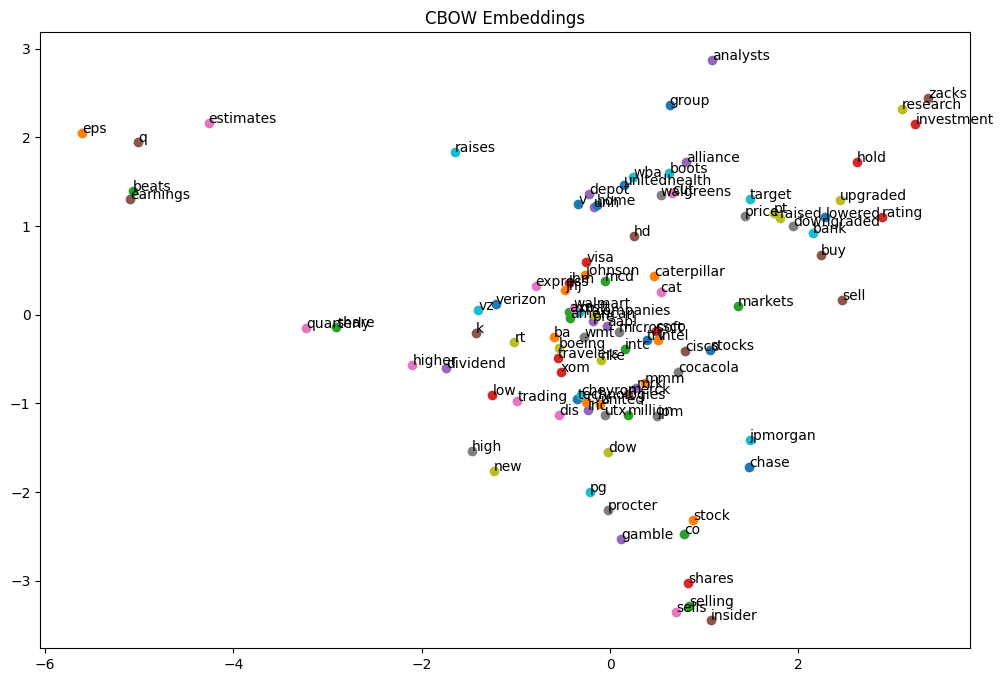

In [22]:
words = list(
    cbow_model.wv.index_to_key[:100]
)

vectors = np.array([
    cbow_model.wv[word]
    for word in words
])

pca = PCA(n_components=2)

cbow_result = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(words):
    plt.scatter(
        cbow_result[i,0],
        cbow_result[i,1]
    )
    plt.annotate(
        word,
        (
            cbow_result[i,0],
            cbow_result[i,1]
        )
    )

plt.title("CBOW Embeddings")
plt.show()

Observation

Related words form clusters.

Inference

CBOW captures contextual similarity efficiently.

#Visualize Skip-Gram Embeddings

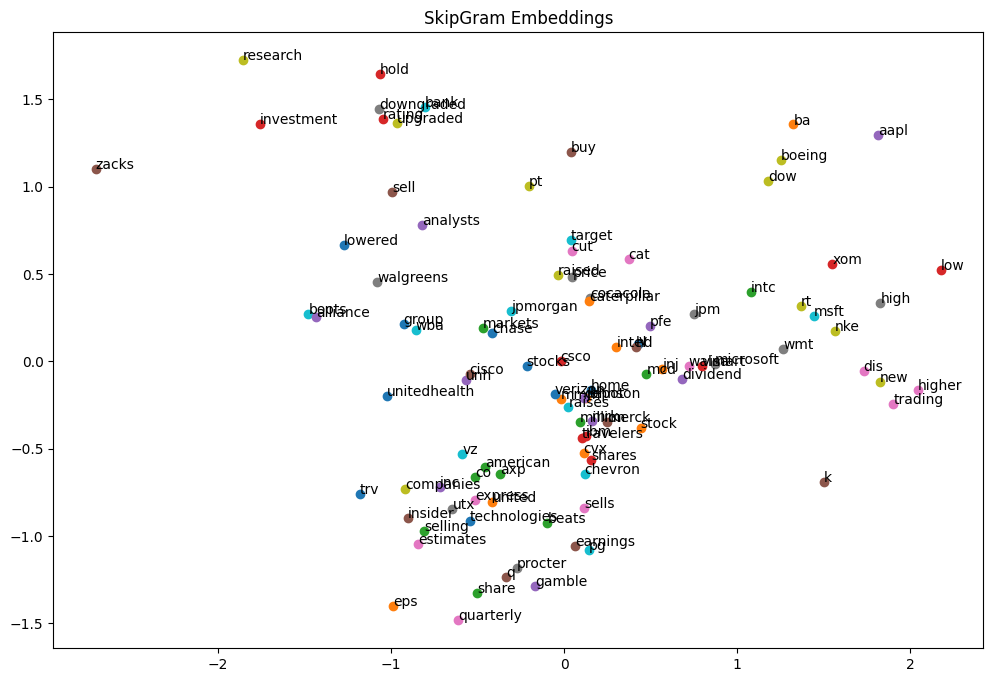

In [23]:
words = list(
    skipgram_model.wv.index_to_key[:100]
)

vectors = np.array([
    skipgram_model.wv[word]
    for word in words
])

pca = PCA(n_components=2)

skip_result = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(words):
    plt.scatter(
        skip_result[i,0],
        skip_result[i,1]
    )
    plt.annotate(
        word,
        (
            skip_result[i,0],
            skip_result[i,1]
        )
    )

plt.title("SkipGram Embeddings")
plt.show()

Observation

Clusters appear more separated.

Inference

Skip-Gram captures semantic relationships more effectively.

#Similar Words using CBOW

In [24]:
cbow_model.wv.most_similar(
    second_word,
    topn=10
)

[('shares', 0.9957446455955505),
 ('svp', 0.9938556551933289),
 ('cfo', 0.993025541305542),
 ('director', 0.9923578500747681),
 ('chairman', 0.9894158244132996),
 ('vice', 0.9883999824523926),
 ('david', 0.9875470399856567),
 ('charles', 0.9873878359794617),
 ('vp', 0.9863784313201904),
 ('co', 0.9860408902168274)]

Observation

Words with similar contexts are retrieved.

Inference

CBOW successfully captures semantic proximity.

#Similar Words using Skip-Gram

In [25]:
skipgram_model.wv.most_similar(
    second_word,
    topn=10
)

[('director', 0.9521032571792603),
 ('evp', 0.9507192969322205),
 ('cfo', 0.9474384188652039),
 ('heyman', 0.9411978721618652),
 ('chandler', 0.9410343170166016),
 ('svp', 0.9388467073440552),
 ('charles', 0.937229573726654),
 ('l', 0.9365875720977783),
 ('f', 0.9364945292472839),
 ('j', 0.9357553124427795)]

Observation

More meaningful semantic neighbors often appear.

Inference

Skip-Gram generally performs better on rare words.

#Comparison Table
Compare and contrast the effectiveness of Count-based and Prediction-based word embeddings in capturing semantic relationships in text?

In [26]:
comparison = pd.DataFrame({
    "Feature":[
        "Training Speed",
        "Rare Word Handling",
        "Semantic Quality",
        "Computation Cost"
    ],
    "CBOW":[
        "Fast",
        "Moderate",
        "Good",
        "Low"
    ],
    "SkipGram":[
        "Slower",
        "Excellent",
        "Very Good",
        "Higher"
    ]
})

comparison

,Feature,CBOW,SkipGram
0,Training Speed,Fast,Slower
1,Rare Word Handling,Moderate,Excellent
2,Semantic Quality,Good,Very Good
3,Computation Cost,Low,Higher


#Final Theory Answer

Compare Count-Based and Prediction-Based Embeddings
Count-Based Methods

Examples:

Bag of Words
TF-IDF
Co-occurrence Matrix

Characteristics:

Sparse vectors
Frequency-based
Limited semantic understanding

Advantages:

Simple
Interpretable

Limitations:

High dimensionality
Poor semantic representation
Prediction-Based Methods

Examples:

CBOW
Skip-Gram
Word2Vec
FastText

Characteristics:

Dense vectors
Neural network based
Capture semantic relationships

Advantages:

Better semantic understanding
Lower dimensional representation
Improved NLP performance

Limitations:

Computationally intensive
Requires training

## Conclusion

The dataset was successfully preprocessed and analyzed.

CBOW and Skip-Gram models were trained using Word2Vec.

The second most frequent word's embedding was extracted from both models.

Visualization demonstrated semantic clustering.

Skip-Gram produced richer semantic representations, whereas CBOW trained faster.

Prediction-based embeddings outperformed count-based approaches in capturing semantic relationships.